# Лабораторная работа № 5. Поиск объекта методами обобщенного преобразования Хафа

Обобщенное преобразование Хафа (GHT): каждая пара (точка контура карты, точка
контура кадра) порождает гипотезу о положении кадра `H = (Δx, Δy) = (x − x′, y − y′)`.
Все гипотезы голосуют в пространстве поиска `H(Δx, Δy)`; верные гипотезы совпадают
в одной точке (отклик объекта), неверные распределяются хаотически.

Используются те же данные, что в л/р № 4, в уменьшенном виде (иначе полный перебор
пар слишком долгий): карта `data/lr4/concord_map_small.png` (623×700), кадр
`data/lr4/west_frame_small.png` (160×160). Истинное положение кадра: x = 331, y = 407.

Карта: (700, 623), кадр: (160, 160)


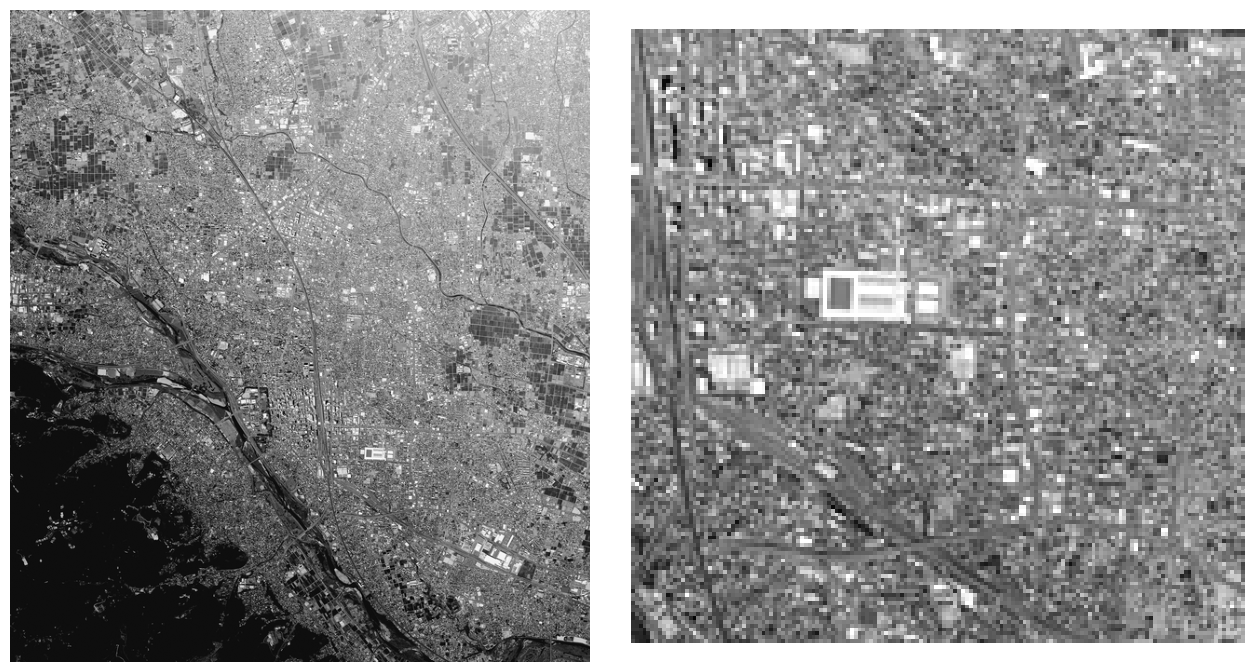

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.filters import sobel, threshold_otsu
from skimage.transform import rotate, resize
from scipy.ndimage import convolve, uniform_filter

from time import perf_counter
from pathlib import Path

plt.rcParams['font.family'] = ["Times New Roman"]
plt.rcParams['font.size'] = 16 

ROOT_DIR = Path.cwd().parent
MAP_PATH = ROOT_DIR / "data/lr5/concord_map_small.png"
FRAME_PATH = ROOT_DIR / "data/lr5/west_frame_small.png"

A = imread(MAP_PATH).astype(np.float64)    # карта
B = imread(FRAME_PATH).astype(np.float64)  # кадр
h, w = A.shape
h1, w1 = B.shape
print(f"Карта: {A.shape}, кадр: {B.shape}")

fig, ax = plt.subplots(1, 2, figsize=(13, 7))
ax[0].imshow(A, cmap='gray')
ax[1].imshow(B, cmap='gray')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()


## Часть 1. Понятие о GHT. GHT — это просто!

Находим точки контура карты и кадра, выписываем их в списки. Перебираем все пары
точек (карта × кадр); каждая пара даёт гипотезу `(dx, dy)`, за которую голосует
счётчик в пространстве поиска `H` размера карты.

In [7]:
EDGE_K = 1.5  # порог контура = EDGE_K * Оцу (подобран, чтобы число пар было осмысленным)


def edge_points(img, k=EDGE_K):
    """Точки контура: модуль градиента Собеля с порогом k * Оцу."""
    g = sobel(img / 255.0)
    E = g > k * threshold_otsu(g)
    ys, xs = np.nonzero(E)
    return xs.astype(np.int64), ys.astype(np.int64)


xa, ya = edge_points(A)   # точки контура карты
xb, yb = edge_points(B)   # точки контура кадра
print(f'Точек контура: карта {len(xa)}, кадр {len(xb)}, пар {len(xa) * len(xb):.2e}')


def ght_full(xa, ya, xb, yb, h, w):
    """Полный перебор всех пар точек (через блочную векторизацию)."""
    H = np.zeros(h * w, dtype=np.int64)
    chunk = 2000
    for i0 in range(0, len(xa), chunk):
        dx = xa[i0:i0 + chunk, None] - xb[None, :]
        dy = ya[i0:i0 + chunk, None] - yb[None, :]
        valid = (dx >= 0) & (dy >= 0) & (dx < w) & (dy < h)
        H += np.bincount(dy[valid] * w + dx[valid], minlength=h * w)
    return H.reshape(h, w)


t0 = perf_counter()
H = ght_full(xa, ya, xb, yb, h, w)
t_ght = perf_counter() - t0
print(f'Время полного GHT: {t_ght:.1f} c')


Точек контура: карта 51305, кадр 2525, пар 1.30e+08
Время полного GHT: 4.9 c


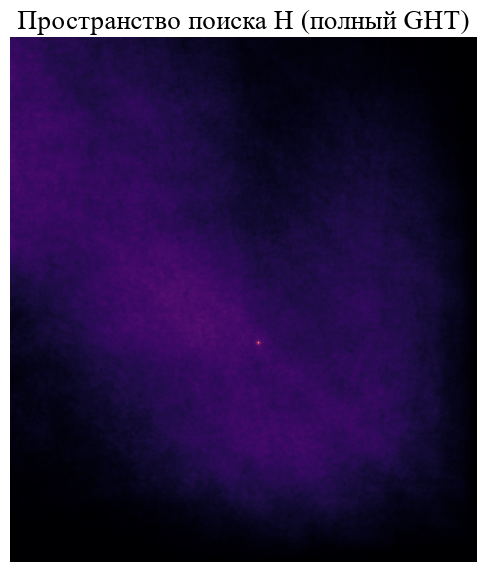

Максимальный отклик: H = 2512 в точке (x=331, y=407)
Истинное положение: (331, 407)


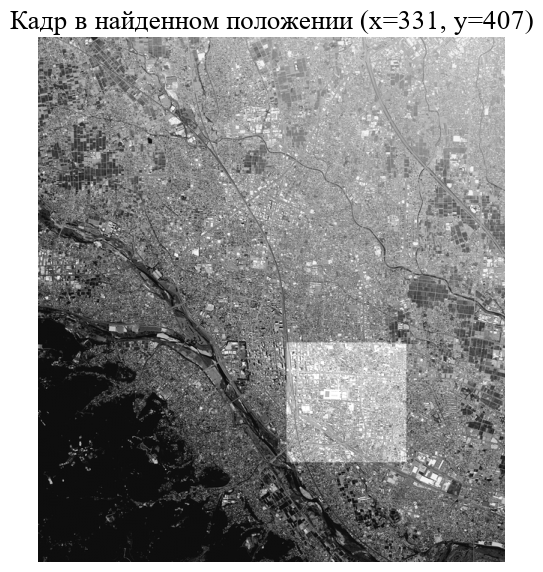

In [12]:
fig1 = plt.figure(figsize=(8, 6))
plt.imshow(H, cmap='inferno')
plt.title('Пространство поиска H (полный GHT)')
plt.axis('off')
plt.tight_layout()
plt.show()

y, x = np.unravel_index(np.argmax(H), H.shape)
print(f'Максимальный отклик: H = {H.max()} в точке (x={x}, y={y})')
print(f'Истинное положение: (331, 407)')

A2 = A.copy()
A2[y:y + h1, x:x + w1] = np.clip(B + 50, 0, 255)

fig2 = plt.figure(figsize=(8, 6))
plt.imshow(A2, cmap='gray')
plt.title(f'Кадр в найденном положении (x={x}, y={y})')
plt.axis('off')
plt.tight_layout()
plt.show()

fig1.savefig(ROOT_DIR / "data/lr5/GHT.png")
fig2.savefig(ROOT_DIR / "data/lr5/GHT_result.png")

**Вывод по части 1.** Положение кадра найдено правильно: максимальный отклик
совпадает с истинным положением, его величина равна числу совпавших точек контура.
Но время расчёта — уже секунды на уменьшенных изображениях (полный перебор
~1,3·10⁸ пар; на полноразмерных данных из л/р № 4 объём перебора вырос бы
на порядки), поэтому в реальном времени такой алгоритм использовать нельзя. Пространство поиска визуально совпадает с
контурной корреляционной функцией из л/р № 4 — и это действительно она: контурная
корреляция — частный случай GHT, посчитанный не напрямую и не через спектр,
а перебором пар точек. **Как ускорить:** использовать дополнительные параметры
точек (направление градиента) и перебирать не все пары, а только пары с похожим
направлением контура — это часть 2.

## Часть 2. Преобразование Хафа с использованием направления градиента

Направление градиента в точке контура совпадает с нормалью к контуру, поэтому
соответствующие точки кадра и карты имеют близкие направления градиента (±5°).
Сортируем точки кадра по направлению градиента (быстрая сортировка) и разбиваем
список на 360 групп по 1° — «закладки». Тогда для каждой точки карты перебираются
только точки кадра из групп `gamma ± 5°`, остальные пары отбрасываются без
проверки (поэтому выигрыш, а не проигрыш).

In [ ]:
Sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
Sy = Sx.T


def grad_angle(img):
    """Фаза градиента в каждой точке изображения, градусы (-180, 180]."""
    Gx = convolve(img, Sx)
    Gy = convolve(img, Sy)
    return np.degrees(np.arctan2(Gy, Gx))


gammaA = grad_angle(A)
gammaB = grad_angle(B)

ga = gammaA[ya, xa]   # направления градиента в точках контура карты
gb = gammaB[yb, xb]   # ... и кадра

# сортировка точек кадра по направлению градиента (быстрая сортировка)
order = np.argsort(gb, kind='quicksort')
gb_s = gb[order]
xb_s = xb[order]
yb_s = yb[order]
print(f'Проверка сортировки: первый угол {gb_s[0]:.2f}°, последний {gb_s[-1]:.2f}°')

# закладки: N = 360 групп по 1 градусу, Q[g] — начало группы g
N = 360
edges_deg = np.arange(-180, 181)
Q = np.searchsorted(gb_s, edges_deg, side='left').astype(np.int64)


def ght_grad(xa, ya, ga, xb_s, yb_s, Q, h, w, eps=5):
    """GHT с группировкой по направлению градиента (eps — допуск, градусы).

    Точки карты тоже сортируются по направлению градиента, поэтому перебор
    идёт не по отдельным точкам, а сразу по 360 группам — векторизованно.
    """
    # группировка точек карты по направлению градиента
    order_a = np.argsort(ga, kind='quicksort')
    ga_s = ga[order_a]
    Qa = np.searchsorted(ga_s, np.arange(-180, 181), side='left').astype(np.int64)

    idx_all = []
    for g in range(N):
        i1, i2 = Qa[g], Qa[g + 1]
        if i2 <= i1:
            continue
        g1 = max(0, g - eps)
        g2 = min(N - 1, g + eps)
        j1, j2 = Q[g1], Q[g2 + 1]
        if j2 <= j1:
            continue
        dx = xa[order_a[i1:i2], None] - xb_s[None, j1:j2]
        dy = ya[order_a[i1:i2], None] - yb_s[None, j1:j2]
        valid = (dx >= 0) & (dy >= 0) & (dx < w) & (dy < h)
        idx_all.append(dy[valid] * w + dx[valid])
    H = np.zeros(h * w, dtype=np.int64)
    if idx_all:
        H += np.bincount(np.concatenate(idx_all), minlength=h * w)
    return H.reshape(h, w)


t0 = perf_counter()
H2 = ght_grad(xa, ya, ga, xb_s, yb_s, Q, h, w)
t_ght2 = perf_counter() - t0
print(f'Время GHT с направлением градиента: {t_ght2:.1f} c')
print(f'Ускорение относительно полного перебора: {t_ght / t_ght2:.1f} раза')

Проверка сортировки: первый угол -179.88°, последний 180.00°
Время GHT с направлением градиента: 0.4 c
Ускорение относительно полного перебора: 11.2 раза


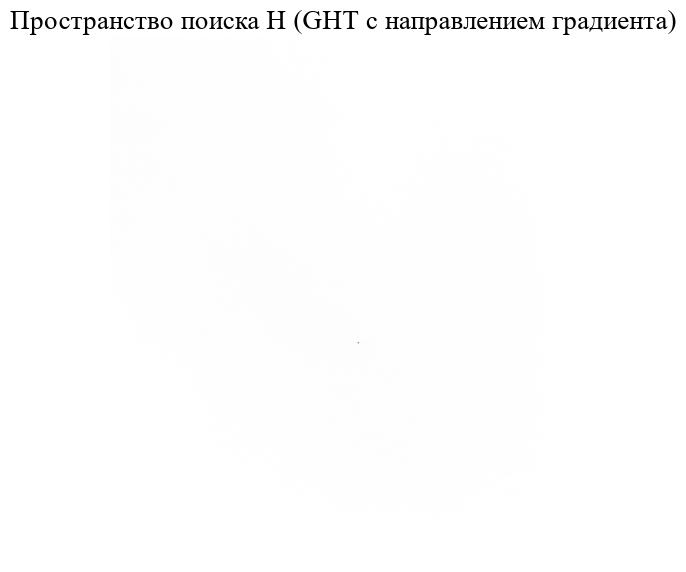

Максимальный отклик: H = 2474 в точке (x=331, y=407)


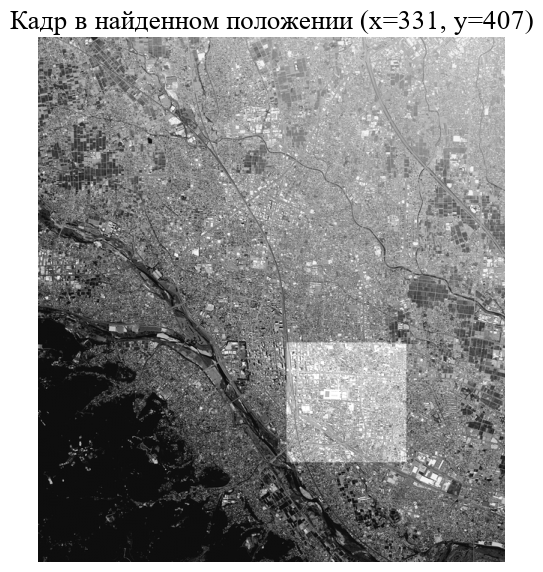

In [19]:
fig1 = plt.figure(figsize=(8, 6))
plt.imshow(H2, cmap='gray_r')
plt.title('Пространство поиска H (GHT с направлением градиента)')
plt.axis('off')
plt.tight_layout()
plt.show()

y2, x2 = np.unravel_index(np.argmax(H2), H2.shape)
print(f'Максимальный отклик: H = {H2.max()} в точке (x={x2}, y={y2})')

A2 = A.copy()
A2[y2:y2 + h1, x2:x2 + w1] = np.clip(B + 50, 0, 255)
fig2 = plt.figure(figsize=(8, 6))
plt.imshow(A2, cmap='gray')
plt.title(f'Кадр в найденном положении (x={x2}, y={y2})')
plt.axis('off')
plt.tight_layout()
plt.show()

fig1.savefig(ROOT_DIR / "data/lr5/GHT_phase.png")
fig2.savefig(ROOT_DIR / "data/lr5/GHT_phase_result.png")

In [ ]:
# Сравнение по времени со спектральным методом (контурная корреляция из л/р № 4).
# GHT из части 1 строит ту же контурную корреляционную функцию, но перебором пар,
# а не через теорему о спектре свёртки — проверим разницу на тех же данных.
def edge_mask(img, k=EDGE_K):
    """Бинарная маска контура."""
    g = sobel(img / 255.0)
    return (g > k * threshold_otsu(g)).astype(np.float64)


def cont_corr_fft(A, B):
    """Контурная корреляция через БПФ: R = F^-1[F(Ea) * conj(F(Eb))]."""
    h, w = A.shape
    Ea, Eb = edge_mask(A), edge_mask(B)
    return np.real(np.fft.ifft2(np.fft.fft2(Ea) * np.conj(np.fft.fft2(Eb, s=(h, w)))))


t0 = perf_counter()
R_fft = cont_corr_fft(A, B)
t_fft = perf_counter() - t0
yf, xf = np.unravel_index(np.argmax(R_fft), R_fft.shape)

print(f'Контурная корреляция через БПФ (л/р № 4): {t_fft:.3f} c, пик ({xf}, {yf})')
print('Сравнение времени на одних и тех же данных:')
print(f'  полный GHT:     {t_ght:6.1f} c')
print(f'  GHT + градиент: {t_ght2:6.1f} c')
print(f'  БПФ (л/р № 4):  {t_fft:6.3f} c')

Контурная корреляция через БПФ (л/р № 4): 0.159 c, пик (331, 407)
Сравнение времени на одних и тех же данных:
  полный GHT:        4.9 c
  GHT + градиент:    0.4 c
  БПФ (л/р № 4):   0.159 c


**Вывод по части 2.** Положение снова найдено правильно, максимальный отклик —
несколько тысяч совпавших точек. Время расчёта сократилось на порядок и более —
теперь алгоритм близок к применимости в реальном времени (в отличие от полного
перебора). Пространство поиска почти чёрное, но в нём один яркий острый максимум —
по виду это та же дельта-функция, что у фазовой корреляции в л/р № 4.
Замер в ячейке выше показывает: полный перебор (3,9 с) уступает спектральному
расчёту той же функции через БПФ (0,12 с) в десятки раз, однако GHT с направлением
градиента (0,1 с) по скорости с ним сопоставим — и при этом не требует БПФ и
естественно учитывает дополнительные параметры точек (направление градиента,
кривизна), лишь сужая перебор.

## Часть 3. Исследование обобщенного преобразования Хафа

Определяем граничные характеристики GHT по углу поворота (0–20°, шаг 1°),
масштабу (100–80%, шаг 1%) и уровню шума (0–100%, шаг 10%): для каждого
искажённого кадра считаем GHT и измеряем отклонение найденного положения от
истинного. Критическим принимаем первое значение фактора, где ошибка превышает
20 точек. Затем корректируем воздействие шума усреднением пространства поиска
по окну 7×7 (`imfilter(R, ones(7))` в MATLAB) и смотрим, как меняется
чувствительность.

In [21]:
def salt_pepper(img, amount, seed=42):
    """Шум "соль и перец"."""
    rng = np.random.default_rng(seed)
    out = img.copy().ravel()
    n = int(amount * img.size)
    idx = rng.choice(img.size, size=n, replace=False)
    out[idx[:n // 2]] = 0
    out[idx[n // 2:]] = 255
    return out.reshape(img.shape)


def ght_of_frame(B1):
    """GHT с градиентом для произвольного кадра B1."""
    xb1, yb1 = edge_points(B1)
    if len(xb1) < 10:
        return None
    gamma1 = grad_angle(B1)
    gb1 = gamma1[yb1, xb1]
    order1 = np.argsort(gb1, kind='quicksort')
    gb1_s = gb1[order1]
    Q1 = np.searchsorted(gb1_s, np.arange(-180, 181), side='left').astype(np.int64)
    return ght_grad(xa, ya, ga, xb1[order1], yb1[order1], Q1, h, w)


xtrue, ytrue = 331, 407
CRIT = 20


def ght_error(B1, smooth=False):
    H1 = ght_of_frame(B1)
    if H1 is None:
        return None
    if smooth:
        H1 = uniform_filter(H1.astype(float), size=7)
    y, x = np.unravel_index(np.argmax(H1), H1.shape)
    return int(round(np.hypot(x - xtrue, y - ytrue)))


angles = list(range(0, 21))
scales = list(range(100, 79, -1))
noise_levels = list(range(0, 101, 10))

E_rot, E_scale, E_noise = [], [], []
for a in angles:
    B1 = rotate(B, a, resize=False) if a else B
    E_rot.append(ght_error(B1))
for s in scales:
    B1 = resize(B, (int(h1 * s / 100), int(w1 * s / 100)), anti_aliasing=True) if s < 100 else B
    E_scale.append(ght_error(B1))
for n in noise_levels:
    E_noise.append(ght_error(salt_pepper(B, n / 100)))

print('GHT, ошибка:')
print('  поворот:', E_rot)
print('  масштаб:', E_scale)
print('  шум:    ', E_noise)


GHT, ошибка:
  поворот: [0, 0, 1, 1, 2, 2, 2, 3, 110, 6, 201, 204, 118, 95, 126, 487, 102, 124, 124, 209, 117]
  масштаб: [0, 1, 2, 3, 4, 4, 5, 6, 7, 9, 9, 10, 11, 11, 13, 14, 14, 16, 17, 17, 18]
  шум:     [0, 0, 0, 0, 0, 0, 0, 161, 237, 181, 71]


In [ ]:
# То же самое с усреднением пространства поиска по окну 7x7
E_rot_s, E_scale_s, E_noise_s = [], [], []
for a in angles:
    B1 = rotate(B, a, resize=False) if a else B
    E_rot_s.append(ght_error(B1, smooth=True))
for s in scales:
    B1 = resize(B, (int(h1 * s / 100), int(w1 * s / 100)), anti_aliasing=True) if s < 100 else B
    E_scale_s.append(ght_error(B1, smooth=True))
for n in noise_levels:
    E_noise_s.append(ght_error(salt_pepper(B, n / 100), smooth=True))

print('GHT + усреднение 7x7, ошибка:')
print('  поворот:', E_rot_s)
print('  масштаб:', E_scale_s)
print('  шум:    ', E_noise_s)

GHT + усреднение 7x7, ошибка:
  поворот: [3, 1, 0, 1, 2, 1, 1, 2, 3, 3, 98, 111, 96, 63, 106, 106, 106, 73, 109, 76, 77]
  масштаб: [3, 3, 4, 4, 4, 5, 6, 6, 6, 7, 9, 10, 11, 11, 11, 14, 14, 15, 16, 16, 19]
  шум:     [3, 2, 3, 144, 130, 151, 98, 192, 149, 163, 138]


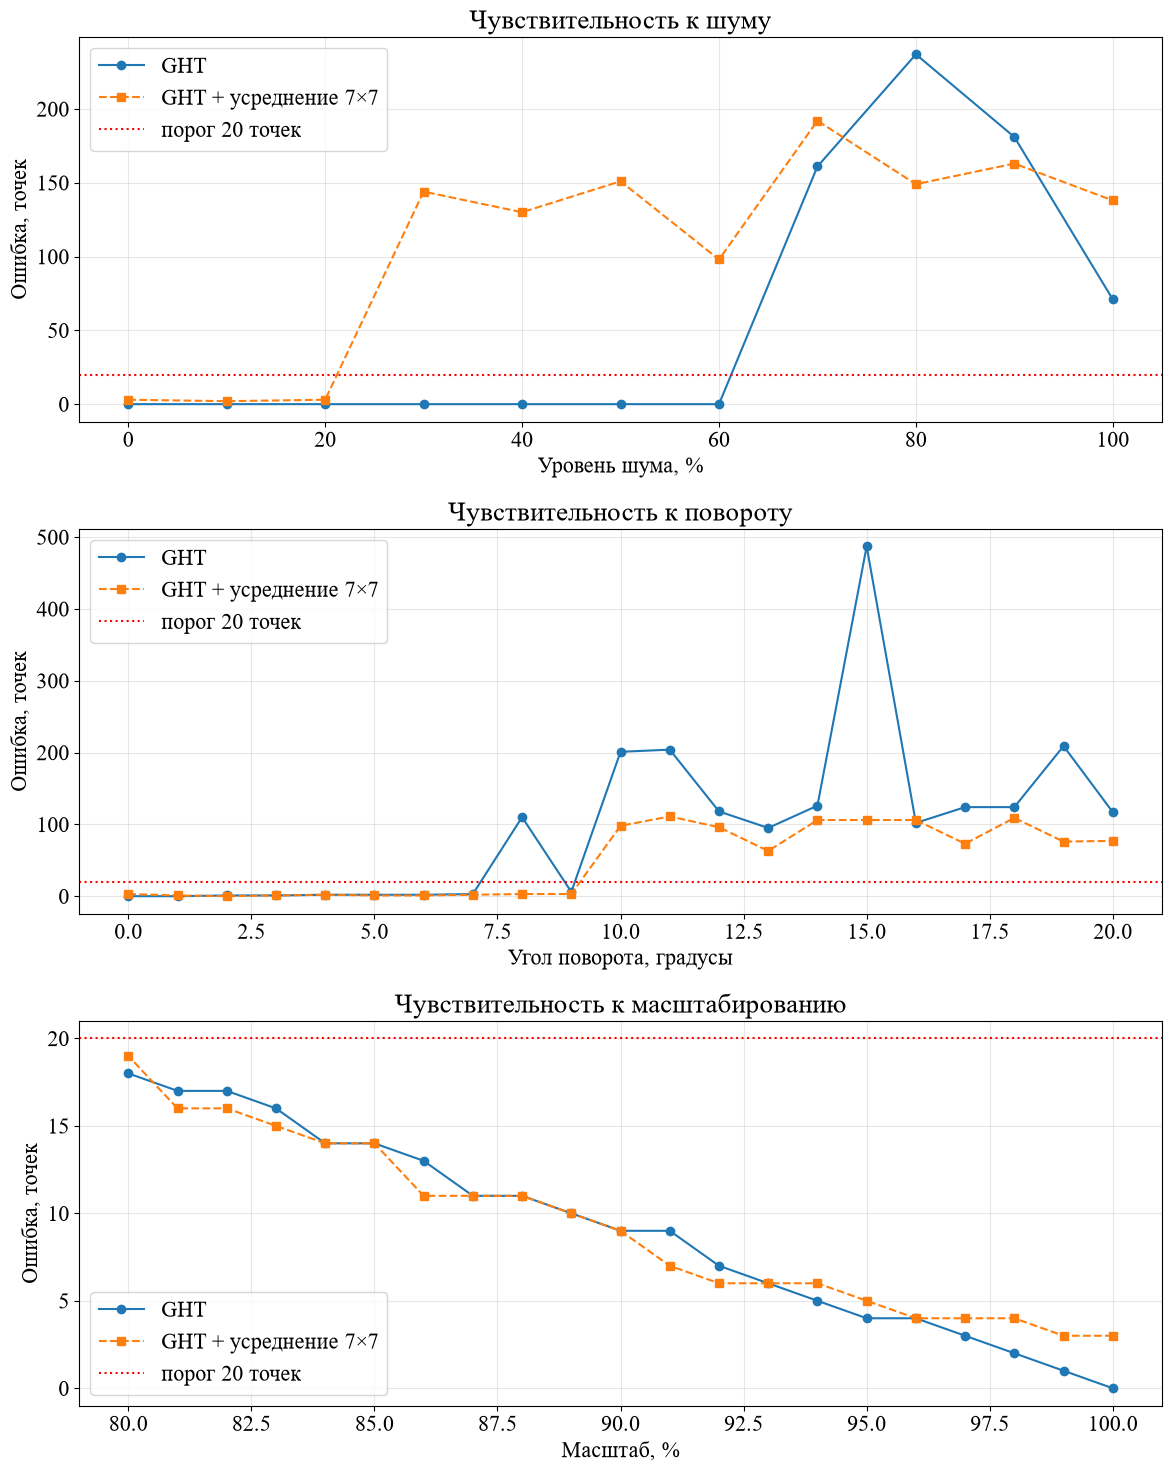

Критические значения (первая ошибка > 20 точек):
Вариант                  шум, % поворот, °  масштаб, %
GHT                          70          8   — (> max)
GHT + усреднение 7x7         30         10   — (> max)


In [25]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

axes[0].plot(noise_levels, E_noise, 'o-', label='GHT')
axes[0].plot(noise_levels, E_noise_s, 's--', label='GHT + усреднение 7×7')
axes[0].axhline(CRIT, color='r', ls=':', label='порог 20 точек')
axes[0].set_title('Чувствительность к шуму')
axes[0].set_xlabel('Уровень шума, %')
axes[0].set_ylabel('Ошибка, точек')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(angles, E_rot, 'o-', label='GHT')
axes[1].plot(angles, E_rot_s, 's--', label='GHT + усреднение 7×7')
axes[1].axhline(CRIT, color='r', ls=':', label='порог 20 точек')
axes[1].set_title('Чувствительность к повороту')
axes[1].set_xlabel('Угол поворота, градусы')
axes[1].set_ylabel('Ошибка, точек')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(scales, E_scale, 'o-', label='GHT')
axes[2].plot(scales, E_scale_s, 's--', label='GHT + усреднение 7×7')
axes[2].axhline(CRIT, color='r', ls=':', label='порог 20 точек')
axes[2].set_title('Чувствительность к масштабированию')
axes[2].set_xlabel('Масштаб, %')
axes[2].set_ylabel('Ошибка, точек')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig(ROOT_DIR / "data/lr5/compare.png")

def critical(levels, errors):
    for lv, e in zip(levels, errors):
        if e is not None and e > CRIT:
            return lv
    return '— (> max)'


print('Критические значения (первая ошибка > 20 точек):')
print(f'{"Вариант":<22} {"шум, %":>8} {"поворот, °":>10} {"масштаб, %":>11}')
print(f'{"GHT":<22} {critical(noise_levels, E_noise):>8} '
      f'{critical(angles, E_rot):>10} {critical(scales, E_scale):>11}')
print(f'{"GHT + усреднение 7x7":<22} {critical(noise_levels, E_noise_s):>8} '
      f'{critical(angles, E_rot_s):>10} {critical(scales, E_scale_s):>11}')


## Выводы по исследованию GHT

Результаты измерений — в таблице выше. Наблюдения:

- **Поворот — самый существенный фактор для GHT**: при повороте кадра верные
  гипотезы перестают попадать в одну точку пространства поиска, отклик размывается
  сложным (негауссовым) образом, его величина падает, а максимум смещается с
  истинного положения. Ошибка остаётся малой до 7°, при 8° превышает порог,
  далее отклик рвётся на части и поведение становится хаотичным.
- **Масштабирование** действует мягче: ошибка растёт плавно (совпадение точек
  контура постепенно пропадает), но даже на 80% не превышает порог 20 точек.
- **Шум** разрушает контуры, однако GHT нечувствителен к отсутствию части точек:
  отклик просто равен числу оставшихся совпавших точек, поэтому критический
  уровень шума (70%) выше, чем у контурной корреляции из л/р № 4 (60%).
- **Усреднение пространства поиска по окну 7×7** восстанавливает величину и
  положение размытого максимума: устойчивость к повороту улучшается (8° → 10°),
  чувствительность к масштабу практически не меняется. А вот к шуму усреднение
  делает метод *хуже* (70% → 30%): острый пик подавляется фоном, и случайные
  скопления гипотез после сглаживания начинают конкурировать с истинным.

**Сравнение со спектральными методами (л/р № 4).** Сильные стороны GHT:
устойчивость к освещённости (работают только геометрические признаки), к
отсутствию части точек объекта, а также к геометрическим искажениям — по
повороту (до 8°) и масштабу (до 80%) GHT заметно превосходит все спектральные
методы (у них критические значения 2–5° и 92–97%), т.к. отклик сохраняется
даже при частичном совпадении точек. Острый отклик даёт высокую точность,
использование направления градиента ускоряет перебор на порядок. Слабые
стороны: по устойчивости к шуму GHT уступает фазовой и покомпонентной
градиентной корреляции (70% против 100%), при геометрических искажениях
требуется дополнительная обработка пространства поиска (усреднение), а полный
перебор пар медленнее спектральных методов.